In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Auto-detect width
pd.set_option('display.max_colwidth', None) # Show full column content

from sklearn.preprocessing import OrdinalEncoder
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

import optuna
import json

In [2]:
df = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
orig = pd.read_excel('orig.xlsx')

In [3]:
df.head(2)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No


In [4]:
orig.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No


In [5]:
for i in orig.columns:
    if i not in list(df.columns):
        print(i)
print("~~")
for j in df.columns:
    if j not in list(orig.columns):
        print(j)

missing = orig.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

customerID
numAdminTickets
numTechTickets
~~
id
Series([], dtype: int64)


In [6]:
orig.drop(['customerID','numAdminTickets','numTechTickets'],axis=1,inplace=True)
df.drop('id',axis=1,inplace=True)
orig.shape

(7043, 20)

In [7]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     289474
Yes                    163993
No internet service    140727
Name: count, dtype: int64

In [8]:
df[df['InternetService'] == 'No']['DeviceProtection'].value_counts()

DeviceProtection
No internet service    140727
Name: count, dtype: int64

In [9]:
print(df.shape)
print(df.dtypes)
print(df.head())

(594194, 20)
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0    Male              0     Yes        Yes      29          Yes   
1    Male              0     Yes        Yes      58          Yes   
2    Male              0     Yes         No      58          Yes   
3  Female              0      No         No       1          Yes   
4  Female              0      No         No       1          Yes   

  Mu

In [10]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

Churn
No     460377
Yes    133817
Name: count, dtype: int64
Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64


In [11]:
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

Series([], dtype: int64)


In [12]:
print(df.describe())  # numerics
print(df.select_dtypes('object').nunique())  # categoricals — cardinality

       SeniorCitizen         tenure  MonthlyCharges   TotalCharges
count  594194.000000  594194.000000   594194.000000  594194.000000
mean        0.114102      36.577258       65.866223    2494.377057
std         0.317936      25.061922       31.067444    2353.916710
min         0.000000       1.000000       18.250000      18.800000
25%         0.000000      12.000000       29.900000     639.650000
50%         0.000000      35.000000       74.100000    1433.650000
75%         0.000000      62.000000       90.800000    4263.800000
max         1.000000      72.000000      118.750000    8684.800000
gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
Churn               2
dtype: int64


In [13]:
cat_cols = df.select_dtypes('object').columns
print(df[cat_cols].nunique().sort_values(ascending=False))

PaymentMethod       4
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
gender              2
Partner             2
Dependents          2
PhoneService        2
PaperlessBilling    2
Churn               2
dtype: int64


In [14]:
print(orig.dtypes)
print(orig.isnull().sum())

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn   

In [15]:
# Fix orig TotalCharges
orig['TotalCharges'] = pd.to_numeric(orig['TotalCharges'], errors='coerce')
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

# Encode target
orig['Churn'] = (orig['Churn'] == 'Yes').astype(int)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Fit on train, transform both
cat_cols = df.select_dtypes('object').columns.tolist()
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[cat_cols] = oe.fit_transform(df[cat_cols])
orig[cat_cols] = oe.transform(orig[cat_cols])
test[cat_cols] = oe.transform(test[cat_cols])  # ← add this

# Cast to category
for col in cat_cols:
    df[col] = df[col].astype('category')
    orig[col] = orig[col].astype('category')
    test[col] = test[col].astype('category')  # ← add this

# Feature engineering
df['charges_per_month'] = df['TotalCharges'] / (df['tenure'] + 1)
orig['charges_per_month'] = orig['TotalCharges'] / (orig['tenure'] + 1)
test['charges_per_month'] = test['TotalCharges'] / (test['tenure'] + 1)  # ← add this

print("Train shape:", df.shape)
print("Orig shape:", orig.shape)
print("Test shape:", test.shape)

Train shape: (594194, 21)
Orig shape: (7043, 21)
Test shape: (254655, 21)


Maybe drop gender, bad predictor?

In [16]:
print(oe.categories_)

[array(['Female', 'Male'], dtype=object), array(['No', 'Yes'], dtype=object), array(['No', 'Yes'], dtype=object), array(['No', 'Yes'], dtype=object), array(['No', 'No phone service', 'Yes'], dtype=object), array(['DSL', 'Fiber optic', 'No'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['No', 'No internet service', 'Yes'], dtype=object), array(['Month-to-month', 'One year', 'Two year'], dtype=object), array(['No', 'Yes'], dtype=object), array(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'], dtype=object)]


In [17]:
# Feature Engineering
#       Did not help
#df['monthly_x_tenure'] = df['MonthlyCharges'] * df['tenure'] 
#df['contract_x_internet'] = df['Contract'].astype(int) * 10 + df['InternetService'].astype(int) #   Way to do it without encoding again...
#df['has_internet'] = (df['InternetService'] != 'No').astype(int)
#df['AdditionalCharges'] = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])
#df['Contract x Monthly'] = df['Contract'].astype(int) * df['MonthlyCharges']
#df['tenure_senior'] = df['tenure'] * df['SeniorCitizen']
#df['tenure_non_senior'] = df['tenure'] * (1 - df['SeniorCitizen'])
#df['service_count'] = sum(df[col].astype(int) == YES_VALUE for col in service_cols)    with service cols
#df['high_value'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)
#df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=[0,1,2,3])

#       Helped
df['charges_per_month'] = df['TotalCharges'] / (df['tenure'] + 1)  # +1 avoids division by zero

In [18]:
def pctrank_against(values, reference):
    ref_sorted = np.sort(reference)
    return (np.searchsorted(ref_sorted, values) / len(ref_sorted)).astype('float32')

def zscore_against(values, reference):
    mu, sigma = np.mean(reference), np.std(reference)
    return (np.zeros(len(values), dtype='float32') if sigma == 0 
            else ((values - mu) / sigma).astype('float32'))

# Get reference distributions from orig
orig_churner_tc    = orig.loc[orig['Churn'] == 1, 'TotalCharges'].values
orig_nonchurner_tc = orig.loc[orig['Churn'] == 0, 'TotalCharges'].values
orig_tc            = orig['TotalCharges'].values
orig_is_mc_mean    = orig.groupby('InternetService')['MonthlyCharges'].mean()

for df_curr in [df, test]:
    tc = df_curr['TotalCharges'].values
    
    df_curr['pctrank_churner_TC']    = pctrank_against(tc, orig_churner_tc)
    df_curr['pctrank_nonchurner_TC'] = pctrank_against(tc, orig_nonchurner_tc)
    df_curr['pctrank_orig_TC']       = pctrank_against(tc, orig_tc)
    df_curr['pctrank_churn_gap_TC']  = (pctrank_against(tc, orig_churner_tc) - 
                                        pctrank_against(tc, orig_nonchurner_tc)).astype('float32')
    df_curr['zscore_churn_gap_TC']   = (np.abs(zscore_against(tc, orig_churner_tc)) - 
                                        np.abs(zscore_against(tc, orig_nonchurner_tc))).astype('float32')
    df_curr['zscore_nonchurner_TC']  = zscore_against(tc, orig_nonchurner_tc)
    df_curr['resid_IS_MC'] = (df_curr['MonthlyCharges'] - 
                              df_curr['InternetService'].astype(float).map(orig_is_mc_mean).fillna(0)).astype('float32')

    # Conditional percentile rank by InternetService
    vals = np.zeros(len(df_curr), dtype='float32')
    for cat_val in orig['InternetService'].unique():
        mask = df_curr['InternetService'].astype(float) == float(cat_val)
        ref = orig.loc[orig['InternetService'].astype(float) == float(cat_val), 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df_curr.loc[mask, 'TotalCharges'].values, ref)
    df_curr['cond_pctrank_IS_TC'] = vals

    # Conditional percentile rank by Contract
    vals = np.zeros(len(df_curr), dtype='float32')
    for cat_val in orig['Contract'].unique():
        mask = df_curr['Contract'].astype(float) == float(cat_val)
        ref = orig.loc[orig['Contract'].astype(float) == float(cat_val), 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df_curr.loc[mask, 'TotalCharges'].values, ref)
    df_curr['cond_pctrank_C_TC'] = vals

print(f"Added distribution features")
print(f"df shape: {df.shape}")
print(f"test shape: {test.shape}")

C:\Users\Chohb\AppData\Local\Temp\ipykernel_18832\1167218933.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orig_is_mc_mean    = orig.groupby('InternetService')['MonthlyCharges'].mean()


Added distribution features
df shape: (594194, 30)
test shape: (254655, 30)


In [19]:
for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:
    ch_q = np.quantile(orig_churner_tc, q_val)
    nc_q = np.quantile(orig_nonchurner_tc, q_val)
    for df_curr in [df, test]:
        df_curr[f'dist_To_ch_{q_label}'] = np.abs(df_curr['TotalCharges'] - ch_q).astype('float32')
        df_curr[f'dist_To_nc_{q_label}'] = np.abs(df_curr['TotalCharges'] - nc_q).astype('float32')
        df_curr[f'qdist_gap_To_{q_label}'] = (df_curr[f'dist_To_nc_{q_label}'] - df_curr[f'dist_To_ch_{q_label}']).astype('float32')

print(f"df shape: {df.shape}")
print(f"test shape: {test.shape}")

df shape: (594194, 39)
test shape: (254655, 39)


In [20]:
X = df.drop('Churn',axis=1)
y = df['Churn']

cat_cols = X.select_dtypes('category').columns.tolist()

skf = StratifiedKFold(n_splits=20,shuffle=True,random_state=16)
preds = np.zeros(len(X))

In [21]:
#   First iteration, LightGBM + default hyperparameters
'''
for fold, (train_i,val_i) in enumerate(skf.split(X,y)):
    X_train, X_val = X.iloc[train_i], X.iloc[val_i]
    y_train, y_val = y.iloc[train_i], y.iloc[val_i]

    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        is_unbalanced=True,
        random_state=16,
        verbose=-1
    )

    model.fit(
        X_train,y_train,
        eval_set=[(X_val,y_val)],
        callbacks=[lgb.early_stopping(50,verbose=False)]      
        )
    
    preds[val_i] = model.predict_proba(X_val)[:,1]
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_val, preds[val_i]):.4f}")

print(f"\nOverall OOF AUC: {roc_auc_score(y,preds):.4f}")'''

'\nfor fold, (train_i,val_i) in enumerate(skf.split(X,y)):\n    X_train, X_val = X.iloc[train_i], X.iloc[val_i]\n    y_train, y_val = y.iloc[train_i], y.iloc[val_i]\n\n    model = lgb.LGBMClassifier(\n        n_estimators=1000,\n        learning_rate=0.05,\n        num_leaves=31,\n        is_unbalanced=True,\n        random_state=16,\n        verbose=-1\n    )\n\n    model.fit(\n        X_train,y_train,\n        eval_set=[(X_val,y_val)],\n        callbacks=[lgb.early_stopping(50,verbose=False)]      \n        )\n    \n    preds[val_i] = model.predict_proba(X_val)[:,1]\n    print(f"Fold {fold+1} AUC: {roc_auc_score(y_val, preds[val_i]):.4f}")\n\nprint(f"\nOverall OOF AUC: {roc_auc_score(y,preds):.4f}")'

Initial OOF AUC: 0.9160

added charges_per_month 
- Overall OOF AUC: 0.9162

In [22]:
'''
lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.tight_layout()
plt.show()
'''

"\nlgb.plot_importance(model, max_num_features=20, importance_type='gain')\nplt.tight_layout()\nplt.show()\n"

In [23]:
#   Optuna for LGB
#       saves best hyperparameters
'''
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1)
        model.fit(X_tr, y_tr,
                  eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    
    return roc_auc_score(y, oof_preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

with open('best_params_lgb.json','w') as f:
    json.dump(study.best_params,f)

'''

'\ndef objective(trial):\n    params = {\n        \'n_estimators\': trial.suggest_int(\'n_estimators\', 500, 2000),\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.01, 0.1),\n        \'num_leaves\': trial.suggest_int(\'num_leaves\', 20, 150),\n        \'min_child_samples\': trial.suggest_int(\'min_child_samples\', 20, 100),\n        \'feature_fraction\': trial.suggest_float(\'feature_fraction\', 0.5, 1.0),\n        \'bagging_fraction\': trial.suggest_float(\'bagging_fraction\', 0.5, 1.0),\n        \'reg_alpha\': trial.suggest_float(\'reg_alpha\', 1e-8, 10.0, log=True),\n        \'reg_lambda\': trial.suggest_float(\'reg_lambda\', 1e-8, 10.0, log=True),\n    }\n    \n    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\n    oof_preds = np.zeros(len(X))\n    \n    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):\n        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]\n        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]\n        \n  

In [24]:
#   Load hyperparams
with open('best_params_lgb.json', 'r') as f:
    best_params_lgb = json.load(f)
print(best_params_lgb)

{'n_estimators': 1231, 'learning_rate': 0.04318732267284199, 'num_leaves': 31, 'min_child_samples': 50, 'feature_fraction': 0.598277037309002, 'bagging_fraction': 0.7593182664803734, 'reg_alpha': 3.413700878114416, 'reg_lambda': 3.368130808601938e-06}


In [ ]:
#   LightGBM + optimal hparams
oof_preds_tuned = np.zeros(len(X))
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**best_params_lgb, random_state=42, verbose=-1)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    oof_preds_tuned[val_idx] = model.predict_proba(X_val)[:, 1]
    models.append(model)
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds_tuned[val_idx]):.4f}")

print(f"\nLGB OOF AUC: {roc_auc_score(y, oof_preds_tuned):.4f}")

Fold 1 AUC: 0.9189
Fold 2 AUC: 0.9185
Fold 3 AUC: 0.9168
Fold 4 AUC: 0.9205
Fold 5 AUC: 0.9164
Fold 6 AUC: 0.9160
Fold 7 AUC: 0.9179
Fold 8 AUC: 0.9192
Fold 9 AUC: 0.9196
Fold 10 AUC: 0.9173
Fold 11 AUC: 0.9183
Fold 12 AUC: 0.9154
Fold 13 AUC: 0.9175
Fold 14 AUC: 0.9171
Fold 15 AUC: 0.9161
Fold 16 AUC: 0.9169
Fold 17 AUC: 0.9172
Fold 18 AUC: 0.9161
Fold 19 AUC: 0.9164
Fold 20 AUC: 0.9177

LGB OOF AUC: 0.9175


0.9166 \
churn-like change (idk?): 0.9172 -> 0.9174 (retuned hp) \
0.9175 quartile change \
5->20 folds: 0.9177 \
Bigrams/trigrams didnt help

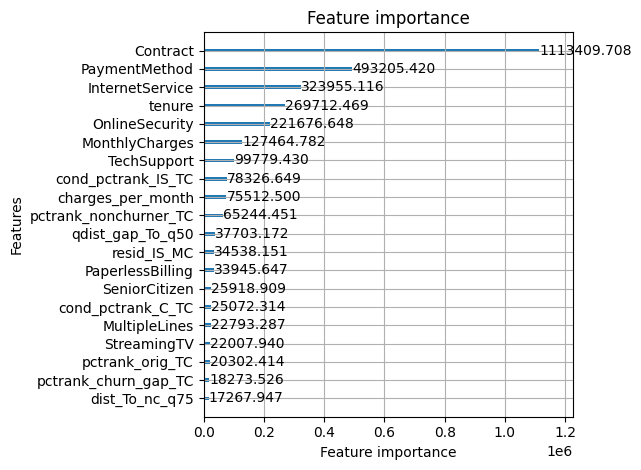

In [120]:
lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.tight_layout()
plt.show()

In [53]:
'''#   XGBoost + Default hyperparams

from xgboost import XGBClassifier

oof_preds_xgb = np.zeros(len(X))
xgb_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='auc',
        enable_categorical=True,
        random_state=16,
        verbosity=0
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    oof_preds_xgb[val_idx] = model.predict_proba(X_val)[:, 1]
    xgb_models.append(model)
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds_xgb[val_idx]):.4f}")

print(f"\nXGB OOF AUC: {roc_auc_score(y, oof_preds_xgb):.4f}")'''

'#   XGBoost + Default hyperparams\n\nfrom xgboost import XGBClassifier\n\noof_preds_xgb = np.zeros(len(X))\nxgb_models = []\n\nfor fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):\n    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]\n    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]\n    \n    model = XGBClassifier(\n        n_estimators=1000,\n        learning_rate=0.05,\n        max_depth=6,\n        subsample=0.8,\n        colsample_bytree=0.8,\n        eval_metric=\'auc\',\n        enable_categorical=True,\n        random_state=16,\n        verbosity=0\n    )\n    model.fit(\n        X_tr, y_tr,\n        eval_set=[(X_val, y_val)],\n        verbose=False\n    )\n    \n    oof_preds_xgb[val_idx] = model.predict_proba(X_val)[:, 1]\n    xgb_models.append(model)\n    print(f"Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds_xgb[val_idx]):.4f}")\n\nprint(f"\nXGB OOF AUC: {roc_auc_score(y, oof_preds_xgb):.4f}")'

In [121]:
#gpu

# Test GPU availability
test_model = XGBClassifier(tree_method='hist', device='cuda', enable_categorical=True)
test_model.fit(X.iloc[:1000], y.iloc[:1000])
print("GPU works!")

GPU works!


In [55]:
#   Optuna for XGB
'''
def xgb_objective(trial):
    params = {
    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
    'max_depth': trial.suggest_int('max_depth', 3, 10),
    'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
    'subsample': trial.suggest_float('subsample', 0.5, 1.0),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
    'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    'enable_categorical': True,
    'eval_metric': 'auc',
    'n_estimators': 2000,
    'tree_method': 'hist',  # ← add this
    'device': 'cuda',       # ← add this
    'random_state': 42,
    'verbosity': 0
}
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    
    return roc_auc_score(y, oof_preds)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=50)

print("Best XGB AUC:", study_xgb.best_value)
print("Best params:", study_xgb.best_params)

with open('best_params_xgb.json','w') as f:
    json.dump(study_xgb.best_params,f)
'''

'\ndef xgb_objective(trial):\n    params = {\n    \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.01, 0.1),\n    \'max_depth\': trial.suggest_int(\'max_depth\', 3, 10),\n    \'min_child_weight\': trial.suggest_int(\'min_child_weight\', 1, 50),\n    \'subsample\': trial.suggest_float(\'subsample\', 0.5, 1.0),\n    \'colsample_bytree\': trial.suggest_float(\'colsample_bytree\', 0.5, 1.0),\n    \'reg_alpha\': trial.suggest_float(\'reg_alpha\', 1e-8, 10.0, log=True),\n    \'reg_lambda\': trial.suggest_float(\'reg_lambda\', 1e-8, 10.0, log=True),\n    \'enable_categorical\': True,\n    \'eval_metric\': \'auc\',\n    \'n_estimators\': 2000,\n    \'tree_method\': \'hist\',  # ← add this\n    \'device\': \'cuda\',       # ← add this\n    \'random_state\': 42,\n    \'verbosity\': 0\n}\n    \n    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\n    oof_preds = np.zeros(len(X))\n    \n    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):\n        X_tr, X_v

In [122]:
with open('best_params_xgb.json', 'r') as f:
    best_params_xgb = json.load(f)
print(best_params_xgb)

{'learning_rate': 0.06954847302345432, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.7294922171350375, 'colsample_bytree': 0.5651098982908576, 'reg_alpha': 1.7800785871358165, 'reg_lambda': 2.2901200993885523e-05}


In [123]:
#   XGBoost + Best hyperparams

from xgboost import XGBClassifier

oof_preds_xgb = np.zeros(len(X))
xgb_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = XGBClassifier(
        **best_params_xgb,
        n_estimators=2000,
        tree_method='hist',
        device='cuda',
        enable_categorical=True,
        eval_metric='auc',
        random_state=42,
        verbosity=0
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    oof_preds_xgb[val_idx] = model.predict_proba(X_val)[:, 1]
    xgb_models.append(model)
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds_xgb[val_idx]):.4f}")

print(f"\nXGB OOF AUC: {roc_auc_score(y, oof_preds_xgb):.4f}")

Fold 1 AUC: 0.9193
Fold 2 AUC: 0.9188
Fold 3 AUC: 0.9172
Fold 4 AUC: 0.9207
Fold 5 AUC: 0.9167
Fold 6 AUC: 0.9161
Fold 7 AUC: 0.9181
Fold 8 AUC: 0.9192
Fold 9 AUC: 0.9200
Fold 10 AUC: 0.9177
Fold 11 AUC: 0.9189
Fold 12 AUC: 0.9160
Fold 13 AUC: 0.9181
Fold 14 AUC: 0.9176
Fold 15 AUC: 0.9167
Fold 16 AUC: 0.9173
Fold 17 AUC: 0.9178
Fold 18 AUC: 0.9165
Fold 19 AUC: 0.9169
Fold 20 AUC: 0.9180

XGB OOF AUC: 0.9179


0.9164 \
0.9168 (fixed issue with optimized params) \
0.9174 (churn-like change idk) (same w/ opt hp) \
0.9177 (quartile change)

In [124]:
# Simple average of LGB and XGB
ensemble_oof = (oof_preds_tuned + oof_preds_xgb) / 2
print(f"LGB + XGB Ensemble OOF AUC: {roc_auc_score(y, ensemble_oof):.4f}")

LGB + XGB Ensemble OOF AUC: 0.9180


In [125]:
#   quickly check corr between the 2
corr = np.corrcoef(oof_preds_tuned, oof_preds_xgb)[0,1]
print(f"Prediction correlation: {corr:.4f}")

Prediction correlation: 0.9973


optimized lgb + default xgb ensemble: 0.9168 \
optimized both lgb + xgb ensemble: 0.9169 \
(quartile on totalcharges): 0.9178

In [126]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Sun Mar 15 03:49:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.57                 Driver Version: 576.57         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   72C    P8             11W /   72W |     133MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
#   CatBoost + default hparams
'''
from catboost import CatBoostClassifier

# Just test if full iterations helps
oof_preds_cat = np.zeros(len(X))
cat_models = []

X_cat = X.copy()
for col in cat_cols:
    X_cat[col] = X_cat[col].astype(str)

cat_features = [X.columns.get_loc(col) for col in cat_cols]

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cat, y)):
    X_tr, X_val = X_cat.iloc[train_idx], X_cat.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.05,
        depth=6,
        eval_metric='AUC',
        cat_features=cat_features,
        early_stopping_rounds=50,  
        random_seed=42,
        verbose=0,
        task_type='GPU'  # use GPU
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    
    oof_preds_cat[val_idx] = model.predict_proba(X_val)[:, 1]
    cat_models.append(model)
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds_cat[val_idx]):.4f}")

print(f"\nCatBoost OOF AUC: {roc_auc_score(y, oof_preds_cat):.4f}")
'''

CB is not helping our ensemble score. Optimizing parameters doesnt change auc. \
CB default hparams: 0.9148 \
(with new df features): 0.9170

In [ ]:
#   Optuna for CatBoost
'''
def cat_objective(trial):
    params = {
        'iterations': 2000,
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.1),  # tighter range
        'depth': trial.suggest_int('depth', 4, 8),  # reduced from 10
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-4, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 1e-4, 5.0, log=True),
        'border_count': trial.suggest_int('border_count', 64, 200),  # tighter range
        'eval_metric': 'AUC',
        'cat_features': cat_features,
        'early_stopping_rounds': 50,
        'random_seed': 42,
        'verbose': 0,
        'task_type': 'GPU'
    }

    X_cat = X.copy()
    for col in cat_cols:
        X_cat[col] = X_cat[col].astype(str)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X_cat))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_cat, y)):
        X_tr, X_val = X_cat.iloc[train_idx], X_cat.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val))

        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    return roc_auc_score(y, oof_preds)

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(cat_objective, n_trials=10)

print("Best CatBoost AUC:", study_cat.best_value)
print("Best params:", study_cat.best_params)

with open('best_params_cat.json', 'w') as f:
    json.dump(study_cat.best_params, f)
'''

In [127]:
print(f"LGB OOF:      {roc_auc_score(y, oof_preds_tuned):.4f}")
print(f"XGB OOF:      {roc_auc_score(y, oof_preds_xgb):.4f}")

print(f"LGB vs XGB corr:      {np.corrcoef(oof_preds_tuned, oof_preds_xgb)[0,1]:.4f}")

# Test ensemble
ensemble_two = (oof_preds_tuned + oof_preds_xgb) / 2
print(f"\nLGB + XGB:             {roc_auc_score(y, ensemble_two):.4f}")

LGB OOF:      0.9177
XGB OOF:      0.9179
LGB vs XGB corr:      0.9973

LGB + XGB:             0.9180


In [128]:
#           Final Ensembled Predictions
#   catboost is bad.
X_test = test.drop(columns=['id']) 

lgb_test_preds = np.zeros(len(X_test))
xgb_test_preds = np.zeros(len(X_test))

for model in models:  # lgb models
    lgb_test_preds += model.predict_proba(X_test)[:, 1]
lgb_test_preds /= 5

for model in xgb_models:
    xgb_test_preds += model.predict_proba(X_test)[:, 1]
xgb_test_preds /= 5

final_preds = (lgb_test_preds + xgb_test_preds) / 2

submission = pd.DataFrame({
    'id': test['id'],
    'Churn': final_preds
})
submission.to_csv('submission.csv', index=False)

In [129]:
ensemble_oof = (oof_preds_tuned + oof_preds_xgb) / 2
print(f"Ensemble OOF AUC: {roc_auc_score(y, ensemble_oof):.4f}")

Ensemble OOF AUC: 0.9180


In [130]:
#   Stacking

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler

# Stack OOF predictions as features
stack_train = np.column_stack([oof_preds_tuned, oof_preds_xgb])
print(f"Stack train shape: {stack_train.shape}")

# Train meta model with CV to avoid overfitting
from sklearn.model_selection import cross_val_score

# Option 1 — Logistic Regression
meta_lr = LogisticRegression()
meta_lr.fit(stack_train, y)
meta_preds_lr = meta_lr.predict_proba(stack_train)[:, 1]
print(f"Stacked LR OOF AUC: {roc_auc_score(y, meta_preds_lr):.4f}")

# Option 2 — simple weighted average optimized
from scipy.optimize import minimize

def neg_auc(weights):
    w = weights / weights.sum()
    blended = w[0] * oof_preds_tuned + w[1] * oof_preds_xgb
    return -roc_auc_score(y, blended)

result = minimize(neg_auc, x0=[0.5, 0.5], method='Nelder-Mead')
best_weights = result.x / result.x.sum()
print(f"\nOptimal weights: LGB={best_weights[0]:.3f}, XGB={best_weights[1]:.3f}")
blended = best_weights[0] * oof_preds_tuned + best_weights[1] * oof_preds_xgb
print(f"Optimized blend OOF AUC: {roc_auc_score(y, blended):.4f}")

Stack train shape: (594194, 2)
Stacked LR OOF AUC: 0.9180

Optimal weights: LGB=0.394, XGB=0.606
Optimized blend OOF AUC: 0.9180


We have a 0.0026 gap between kaggle AUC and our AUC. Kaggle scored 0.91423, we scored 0.9168 \
(churn-like changes): 0.9175 local \
0.9178 (quartile)

In [65]:
print("OOF preds:")
print(f"min={oof_preds_tuned.min():.4f}, max={oof_preds_tuned.max():.4f}, mean={oof_preds_tuned.mean():.4f}")

print("\nLGB test preds:")
print(f"min={lgb_test_preds.min():.4f}, max={lgb_test_preds.max():.4f}, mean={lgb_test_preds.mean():.4f}")

print("\nXGB test preds:")
print(f"min={xgb_test_preds.min():.4f}, max={xgb_test_preds.max():.4f}, mean={xgb_test_preds.mean():.4f}")

print("\nFinal ensemble preds:")
print(f"min={final_preds.min():.4f}, max={final_preds.max():.4f}, mean={final_preds.mean():.4f}")

OOF preds:
min=0.0002, max=0.9867, mean=0.2252

LGB test preds:
min=0.0002, max=0.9842, mean=0.2182

XGB test preds:
min=0.0001, max=0.9899, mean=0.2182

Final ensemble preds:
min=0.0002, max=0.9865, mean=0.2182
